Important: Only a small portion of the dataset is included here for demonstration purposes. The notebook workflow and analysis remain the same as the full project.

## 📋 Project Overview

This project focuses on analyzing hospital data to gain insights into patient flow, departmental workload, and overall hospital operations. Using Python and data analysis libraries, the raw hospital data was cleaned, processed, and explored to identify trends and inefficiencies.

The analysis aims to support hospital administrators in making data-driven decisions related to resource allocation, staffing optimization, and operational efficiency. Visualizations and exploratory techniques were used to clearly communicate findings and highlight key patterns within the data.


## 📌 Business Problem

Hospitals generate large volumes of patient and operational data every day. However, without proper analysis, hospital management faces challenges such as:

- Understanding patient admission patterns  
- Identifying high-demand departments  
- Allocating resources like staff and beds efficiently  
- Reducing operational delays and overcrowding  

The lack of data-driven insights can lead to inefficient operations, increased costs, and reduced quality of patient care.


## 🧾 Dataset Overview

The dataset contains hospital-related information such as:

- Patient admissions  
- Department details  
- Length of hospital stay  
- Operational and utilization metrics  

This data is used to study trends, patterns, and inefficiencies within hospital operations.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


In [ ]:
from sqlalchemy import create_engine

username = "#####"
password = "####"   # <-- put your MySQL password
host = "#######"
port = 3306
database = "project"   # <-- your database name

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [ ]:
query = "select * from hospital_resource;"
df = pd.read_sql(query, engine)

In [ ]:
df

,patient_id,visit_date,visit_time,age,gender,city,department,diagnosis_type,triage_level,wait_time_min,treatment_time_min,bed_required,bed_type,ambulance_used,resource_cost_inr,emergency_flag
0,1,2025-11-23,0 days 08:09:16,31,Female,Delhi,Emergency,Asthma,High,33,1058,No,None,No,231.0,0
1,2,2025-09-29,0 days 20:31:06,15,Male,Mumbai,Orthopedics,Accident,Medium,88,1083,No,None,No,126.0,0
2,3,2024-03-04,0 days 22:22:26,20,Female,Bangalore,Emergency,Heart Attack,High,25,1022,No,None,No,119.0,0
3,4,2025-12-15,0 days 10:35:08,14,Male,Bangalore,Emergency,Accident,Low,138,1039,No,None,Yes,186.0,0
4,5,2025-10-19,0 days 10:41:25,75,Male,Chennai,Pediatrics,Fever,Low,177,1041,Yes,General,No,231.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999996,2025-08-13,0 days 15:03:27,60,Male,Bangalore,Cardiology,Heart Attack,High,23,1095,No,None,Yes,120.0,0
999996,999997,2026-01-07,0 days 23:01:57,16,Male,Bangalore,Emergency,Fever,Critical,5,1048,Yes,ICU,Yes,80.0,0
999997,999998,2025-04-19,0 days 14:31:28,16,Male,Mumbai,Emergency,Fever,Low,138,1064,Yes,General,No,226.0,0
999998,999999,2024-07-05,0 days 00:06:25,89,Female,Bangalore,Emergency,Heart Attack,Critical,5,1011,Yes,Ventilator,Yes,31.0,0


In [ ]:
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce')

In [ ]:
df.isna().sum()

patient_id            0
visit_date            0
visit_time            0
age                   0
gender                0
city                  0
department            0
diagnosis_type        0
triage_level          0
wait_time_min         0
treatment_time_min    0
bed_required          0
bed_type              0
ambulance_used        0
resource_cost_inr     0
emergency_flag        0
total_time            0
age_group             0
visit_month           0
visit_day             0
dtype: int64

In [ ]:
Q1 = df['resource_cost_inr'].quantile(0.25)
Q3 = df['resource_cost_inr'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR


df = df.loc[df['resource_cost_inr'] <= upper_limit].copy()

In [ ]:
df['total_time'] = df['wait_time_min'] + df['treatment_time_min']

In [ ]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 35, 60, 120],
    labels=['Child', 'Young', 'Adult', 'Senior']
)



In [ ]:
# Binary mappings (nullable-safe)
df['ambulance_used'] = (
    df['ambulance_used']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
    .astype('Int64')
)


In [ ]:
df.describe(include='all')

,patient_id,visit_date,visit_time,age,gender,city,department,diagnosis_type,triage_level,wait_time_min,treatment_time_min,bed_required,bed_type,ambulance_used,resource_cost_inr,emergency_flag,total_time,age_group,visit_month,visit_day
count,999358.000000,999358,999358,999358.000000,999358,999358,999358,999358,999358,999358.000000,999358.000000,0.0,999358,0.0,999358.000000,999358.0,999358.000000,999358,999358.000000,999358
unique,NaN,NaN,NaN,NaN,2,5,6,6,4,NaN,NaN,<NA>,4,<NA>,NaN,NaN,NaN,4,NaN,7
top,NaN,NaN,NaN,NaN,Female,Bangalore,Emergency,Accident,Low,NaN,NaN,<NA>,None,<NA>,NaN,NaN,NaN,Senior,NaN,Saturday
freq,NaN,NaN,NaN,NaN,500127,200330,350233,221205,327987,NaN,NaN,<NA>,531496,<NA>,NaN,NaN,NaN,324690,NaN,144090
mean,499999.923496,2025-02-08 19:57:12.074592768,0 days 13:21:00.340572647,44.967018,NaN,NaN,NaN,NaN,NaN,61.516855,1049.987096,<NA>,NaN,<NA>,170.959693,0.0,1111.503951,NaN,6.521373,NaN
min,1.000000,2024-02-10 00:00:00,0 days 00:00:00,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1001.000000,<NA>,NaN,<NA>,21.000000,0.0,1002.000000,NaN,1.000000,NaN
25%,249999.250000,2024-08-10 00:00:00,0 days 08:29:00,23.000000,NaN,NaN,NaN,NaN,NaN,19.000000,1025.000000,<NA>,NaN,<NA>,117.000000,0.0,1069.000000,NaN,4.000000,NaN
50%,500000.500000,2025-02-09 00:00:00,0 days 14:25:03,45.000000,NaN,NaN,NaN,NaN,NaN,48.000000,1050.000000,<NA>,NaN,<NA>,170.000000,0.0,1104.000000,NaN,7.000000,NaN
75%,750005.750000,2025-08-11 00:00:00,0 days 20:44:06,67.000000,NaN,NaN,NaN,NaN,NaN,89.000000,1075.000000,<NA>,NaN,<NA>,218.000000,0.0,1149.000000,NaN,10.000000,NaN
max,1000000.000000,2026-02-09 00:00:00,0 days 23:59:59,89.000000,NaN,NaN,NaN,NaN,NaN,179.000000,1099.000000,<NA>,NaN,<NA>,369.000000,0.0,1278.000000,NaN,12.000000,NaN


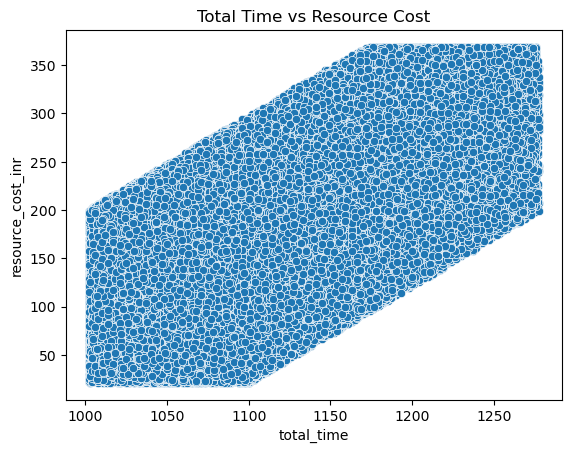

In [ ]:
plt.figure()
sns.scatterplot(x='total_time', y='resource_cost_inr', data=df)
plt.title("Total Time vs Resource Cost")
plt.show()

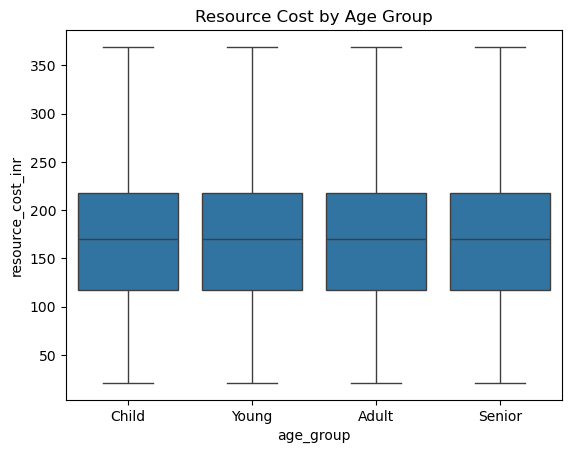

In [ ]:
plt.figure()
sns.boxplot(x='age_group', y='resource_cost_inr', data=df)
plt.title("Resource Cost by Age Group")
plt.show()

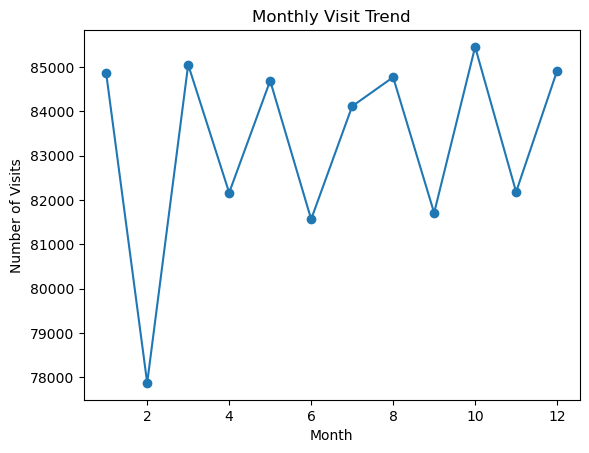

In [ ]:
# ===============================
# 12. MONTHLY VISIT TREND
# ===============================
monthly_visits = df['visit_month'].value_counts().sort_index()

plt.figure()
monthly_visits.plot(kind='line', marker='o')
plt.title("Monthly Visit Trend")
plt.xlabel("Month")
plt.ylabel("Number of Visits")
plt.show()


## 💡 Key Insights

- Certain departments consistently receive higher patient volumes, indicating increased demand for resources.  
- Admission trends reveal peak periods that can help optimize staffing schedules.  
- Some patients experience longer hospital stays, impacting bed availability and operational efficiency.  
- Uneven patient distribution across departments highlights potential inefficiencies in hospital workflow.


## ✅ Conclusion

This project demonstrates how hospital data can be transformed into actionable insights using Python. Through data cleaning, exploratory data analysis, and visualization, key operational patterns were identified.

The analysis highlights the importance of data analytics in improving hospital efficiency, optimizing resources, and enhancing patient care, making this a strong data analyst portfolio project.
